In [17]:
import json
import numpy as np
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
models_to_run_global = [
    "MLPGlobal",
    "GraphSAGEGlobal",
    "GUNetGlobal",
    "PointNetGlobal"
]

datasets = [
    "cls_model_35_default",
    "cls_model_35_normalized",
    "cls_model_35_centered",
    "cls_model_35_Extruded_centered_thin_uniform",
    "cls_model_35_Extruded_default_thin_uniform",
    "cls_model_35_torus_default",
    "cls_model_35_OT_2D",
    "cls_model_35_OT_3D",
    "PointMAE_pretrain_default",
    "PointMAE_pretrain_normalized",
    "PointMAE_pretrain_centered",
    "PointMAE_pretrain_Extruded_centered_thin_uniform",
    "PointMAE_pretrain_Extruded_normalized_thin_uniform",
    "PointMAE_pretrain_torus_normalized",
    "PointMAE_pretrain_OT_2D",
    "PointMAE_pretrain_OT_3D",
]



def compute_mean_std(json_path, key="test_mse_normalized"): #train_loss, val_loss, test_mse_normalized
    """
    Load a JSON file containing a list of runs and compute mean and std
    for the given metric key.
    """
    with open(json_path, "r") as f:
        data = json.load(f)

    values = [d[key] for d in data if key in d]

    # mean = np.mean(values)
    mean = values[-1]
    std  = 0

    return mean, std

DISPLAY_NAMES = {
    "baseline": "Baseline",
    "PointMAE_pretrain_default": "PointMAE",
    "PointMAE_pretrain_normalized": "PointMAE + Norm",
    "PointMAE_pretrain_centered": "PointMAE + Center",
    "PointMAE_pretrain_Extruded_centered_thin_uniform": "PointMAE + Extruded",
    "PointMAE_pretrain_Torus": "PointMAE + Torus",
    "cls_model_35_default": "PointNet",
    "cls_model_35_normalized": "PointNet + Norm",
    "cls_model_35_centered": "PointNet + Center",
    "cls_model_35_Extruded_centered_thin_uniform": "PointNet + Extruded",
    "cls_model_35_Torus": "PointNet + Torus",
}

def plot_empirical_bar(
    df,
    datasets=None,
    models=None,
    title="Test performance (mean ± std)"
):
    if datasets is not None:
        df = df[df["dataset"].isin(datasets)]
    if models is not None:
        df = df[df["model"].isin(models)]

    labels = [DISPLAY_NAMES.get(d, d) for d in df["dataset"].values]
    means  = df["mean_test_mse"].values
    stds   = df["std_test_mse"].values
    gains  = df["gain_pct_vs_baseline"].values

    x = np.arange(len(labels))

    plt.figure(figsize=(10, 5))
    plt.bar(x, means, yerr=stds, capsize=6)
    for i, v in enumerate(means):
        plt.text(
            i,
            v,
            f"{v:.3g}",
            ha="center",
            va="bottom",
            fontsize=9,
        )
    plt.xticks(x, labels, rotation=20)
    plt.ylabel("Test MSE")
    plt.title(title)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))

    colors = ["tab:green" if g > 0 else "tab:red" for g in gains]
    plt.bar(x, gains)
    for i, v in enumerate(gains):
        plt.text(
            i,
            v,
            f"{v:.3g}",
            ha="center",
            va="bottom",
            fontsize=9,
        )
    plt.axhline(0, color="black", linewidth=1)
    plt.xticks(x, labels, rotation=20)
    plt.ylabel("Gain vs baseline (%)")
    plt.title("Relative gain vs baseline")
    plt.tight_layout()
    plt.show()


In [ ]:
import json
import numpy as np
import pandas as pd

rows = []

for model in models_to_run_global:
    base_model = model.replace("Global", "")  
    baseline_path = f"baseline_scarce_1600/metrics/scarce/{base_model}/{base_model}_log.json"
    mean, std = compute_mean_std(baseline_path)
    rows.append({
        "dataset": "baseline",
        "model": base_model,
        "mean_test_mse": mean,
        "std_test_mse": std,
    })
    for dataset in datasets:
        path = f"training_pipeline2_2/metrics/{dataset}/scarce/{model}/{model}_log.json"
        mean, std = compute_mean_std(path)
        rows.append({
            "dataset": dataset,
            "model": model,
            "mean_test_mse": mean,
            "std_test_mse": std,
        })

df = pd.DataFrame(rows)
df["base_model"] = df["model"].str.replace("Global", "", regex=False)
baseline_df = (
    df[df["dataset"] == "baseline"]
    .set_index("base_model")["mean_test_mse"]
)
df["baseline_mse"] = df["base_model"].map(baseline_df)
df["gain_pct_vs_baseline"] = (
    (df["baseline_mse"] - df["mean_test_mse"])
    / df["baseline_mse"]
    * 100
)
df.loc[df["dataset"] == "baseline", "gain_pct_vs_baseline"] = 0.0
df.head(25)





,dataset,model,mean_test_mse,std_test_mse,base_model,baseline_mse,gain_pct_vs_baseline
0,baseline,MLP,0.039132,0,MLP,0.039132,0.000000
1,cls_model_35_default,MLPGlobal,0.031551,0,MLP,0.039132,19.372926
2,cls_model_35_normalized,MLPGlobal,0.034671,0,MLP,0.039132,11.398802
3,cls_model_35_centered,MLPGlobal,0.033844,0,MLP,0.039132,13.512706
4,cls_model_35_Extruded_centered_thin_uniform,MLPGlobal,0.032650,0,MLP,0.039132,16.563884
5,cls_model_35_Extruded_default_thin_uniform,MLPGlobal,0.029391,0,MLP,0.039132,24.891450
6,cls_model_35_torus_default,MLPGlobal,0.029050,0,MLP,0.039132,25.763794
7,cls_model_35_OT_2D,MLPGlobal,0.028192,0,MLP,0.039132,27.956532
8,cls_model_35_OT_3D,MLPGlobal,0.043685,0,MLP,0.039132,-11.636293
9,PointMAE_pretrain_default,MLPGlobal,0.032138,0,MLP,0.039132,17.871793


In [ ]:
df_RQ2_Pointmae = df[df["dataset"] == "PointMAE_pretrain_default"]
df_RQ2_Pointmae.head()


,dataset,model,mean_test_mse,std_test_mse,base_model,baseline_mse,gain_pct_vs_baseline
9,PointMAE_pretrain_default,MLPGlobal,0.032138,0,MLP,0.039132,17.871793
26,PointMAE_pretrain_default,GraphSAGEGlobal,0.027962,0,GraphSAGE,0.029796,6.158043
43,PointMAE_pretrain_default,GUNetGlobal,0.028274,0,GUNet,0.030394,6.975965
60,PointMAE_pretrain_default,PointNetGlobal,0.017898,0,PointNet,0.016124,-11.006236


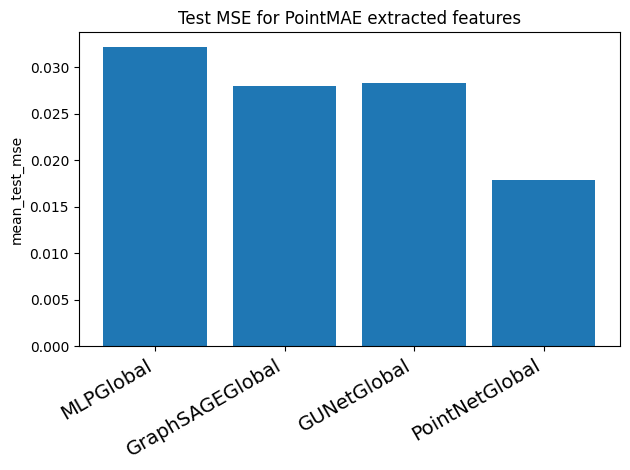

In [21]:
plt.bar(df_RQ2_Pointmae["model"], df_RQ2_Pointmae["mean_test_mse"])
plt.ylabel("mean_test_mse")
plt.title("Test MSE for PointMAE extracted features")
plt.xticks(
    rotation=30,
    ha="right",
    fontsize=14  
)
plt.tight_layout()
plt.show()

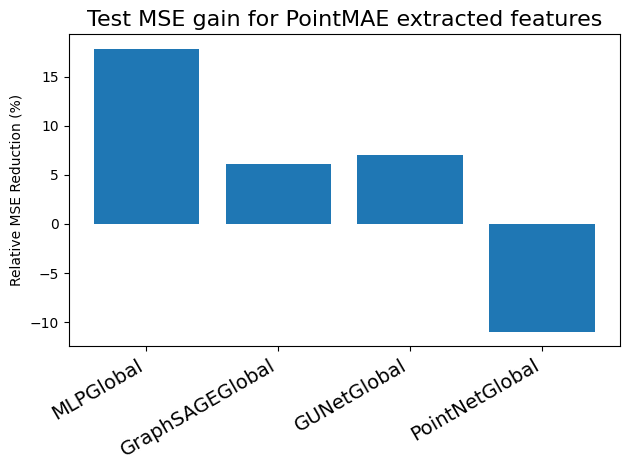

In [33]:
plt.bar(df_RQ2_Pointmae["model"], df_RQ2_Pointmae["gain_pct_vs_baseline"])
plt.ylabel("Relative MSE Reduction (%)")
plt.title("Test MSE gain for PointMAE extracted features",fontdict={"fontsize": 16})
plt.xticks(
    rotation=30,
    ha="right",
    fontsize=14  
)
plt.tight_layout()
plt.show()

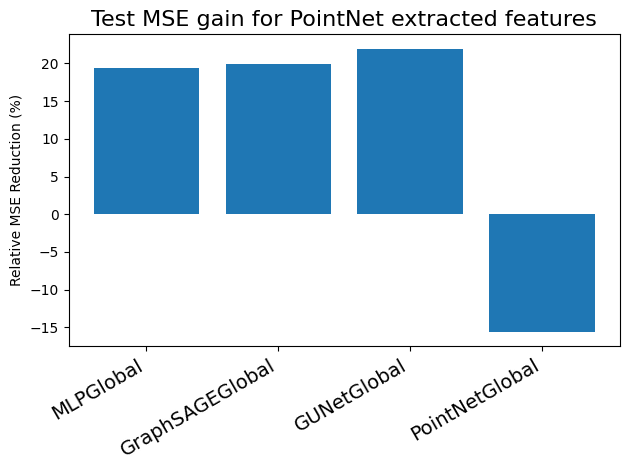

In [34]:
# bar plot
df_RQ2_Pointnet = df[df["dataset"] == "cls_model_35_default"]
df_RQ2_Pointnet.head()
plt.bar(df_RQ2_Pointnet["model"], df_RQ2_Pointnet["gain_pct_vs_baseline"])
plt.ylabel("Relative MSE Reduction (%)")
plt.title("Test MSE gain for PointNet extracted features",fontdict={"fontsize": 16})
plt.xticks(
    rotation=30,
    ha="right",
    fontsize=14  
)
plt.tight_layout()
plt.show()

# MLP

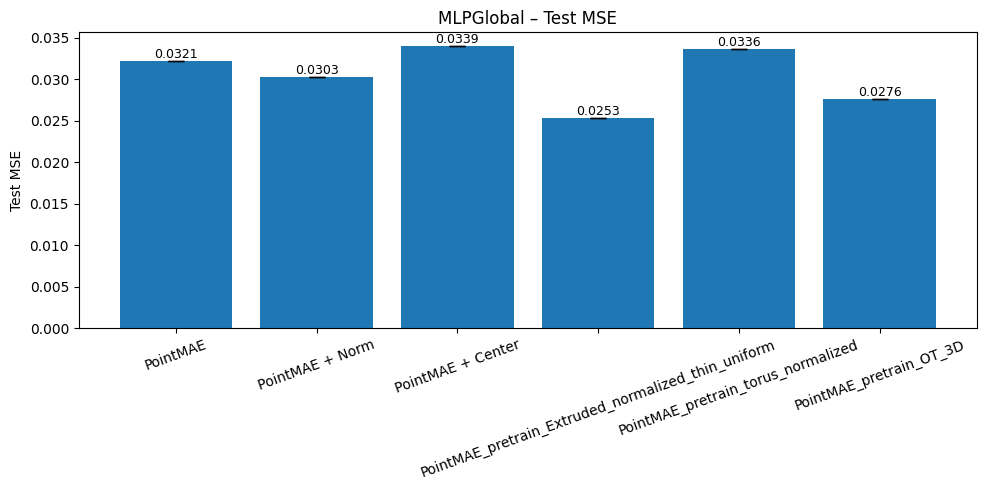

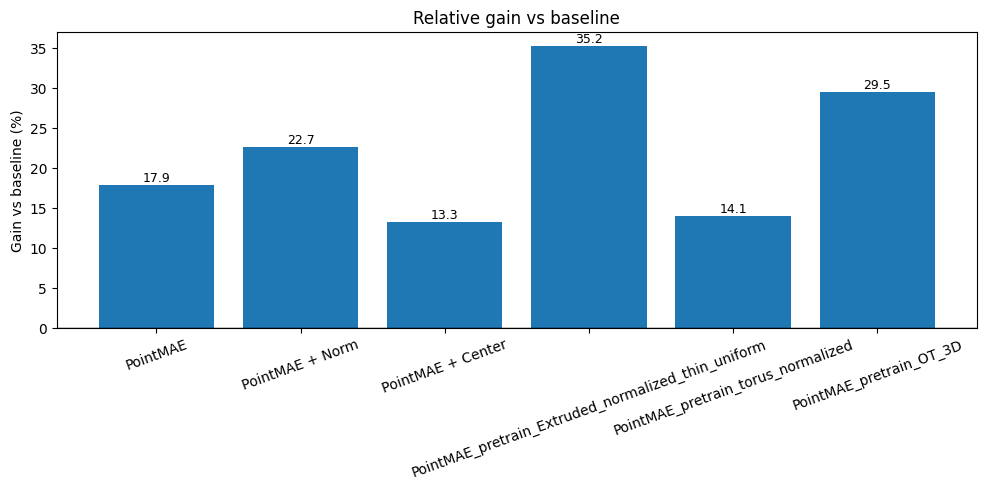

In [24]:
plot_empirical_bar(
    df,
    datasets=[
        "PointMAE_pretrain_default",
        "PointMAE_pretrain_normalized",
        "PointMAE_pretrain_centered",
        "PointMAE_pretrain_Extruded_normalized_thin_uniform",
        "PointMAE_pretrain_torus_normalized",
        "PointMAE_pretrain_OT_3D",
    ],
    models=["MLPGlobal","MLP"],
    title="MLPGlobal – Test MSE"
)

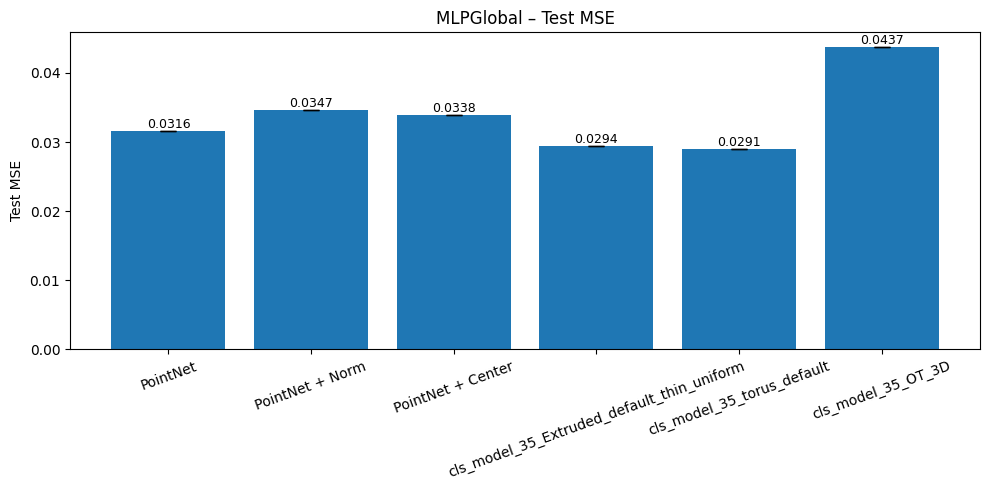

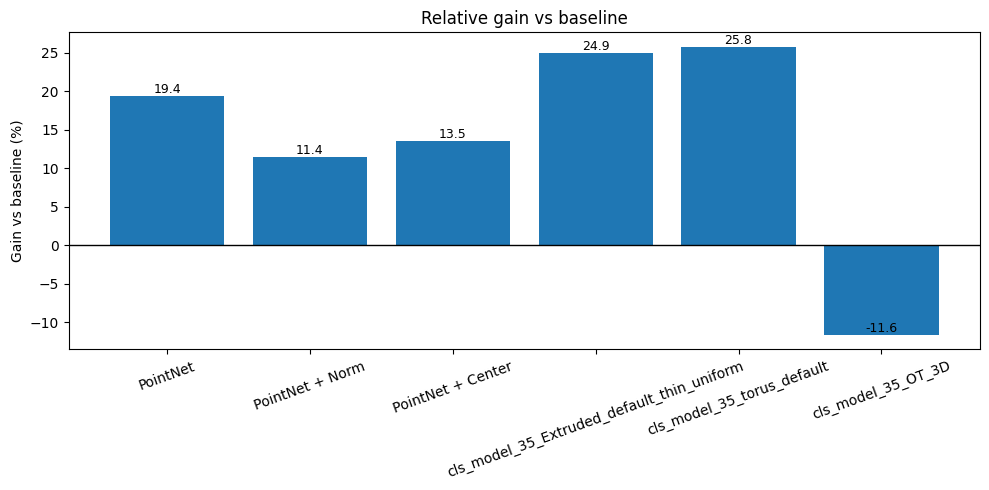

In [25]:
plot_empirical_bar(
    df,
    datasets=[
        "cls_model_35_default",
        "cls_model_35_normalized",
        "cls_model_35_centered",
        "cls_model_35_Extruded_default_thin_uniform",
        "cls_model_35_torus_default",
        "cls_model_35_OT_3D",
    ],
    models=["MLPGlobal","MLP"],
    title="MLPGlobal – Test MSE"
)


# Graph Sage

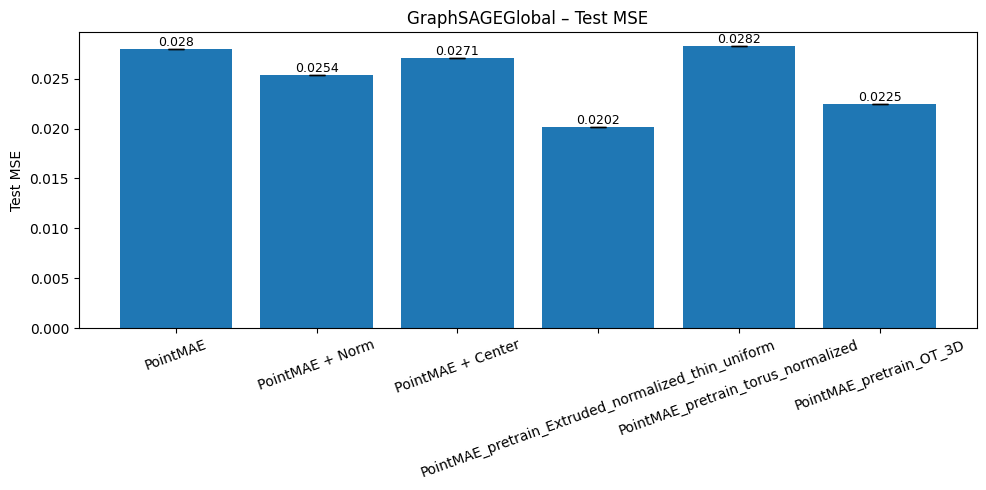

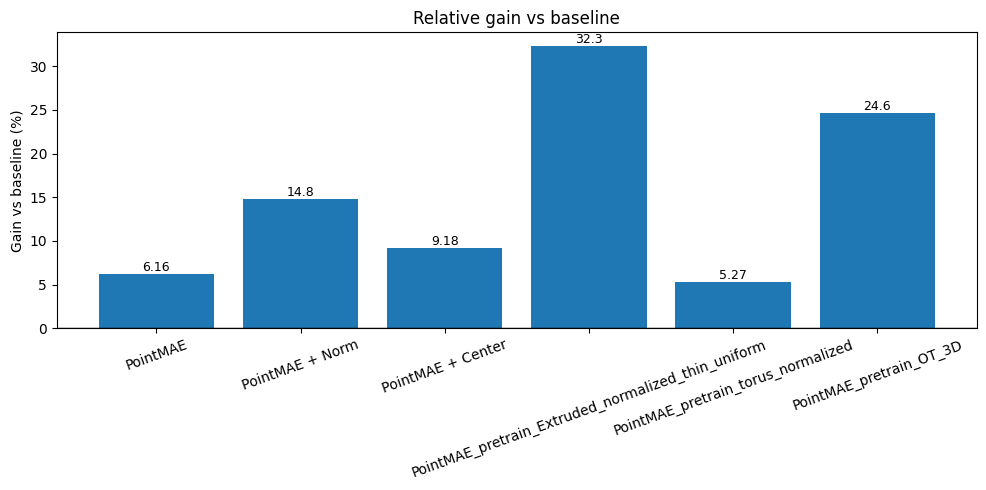

In [26]:
plot_empirical_bar(
    df,
    datasets=[
        "PointMAE_pretrain_default",
        "PointMAE_pretrain_normalized",
        "PointMAE_pretrain_centered",
        "PointMAE_pretrain_Extruded_normalized_thin_uniform",
        "PointMAE_pretrain_torus_normalized",
        "PointMAE_pretrain_OT_3D",
    ],
    models=["GraphSAGEGlobal","GraphSAGE"],
    title="GraphSAGEGlobal – Test MSE"
)


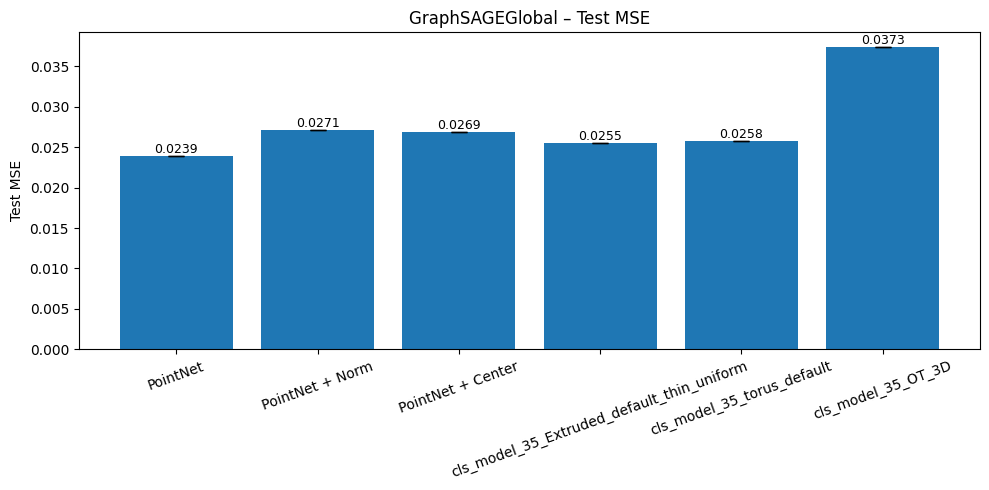

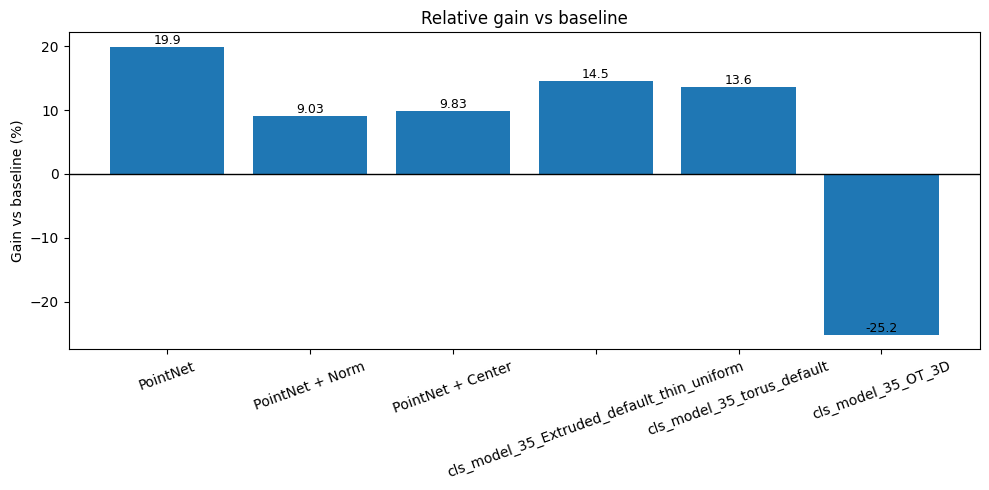

In [27]:
plot_empirical_bar(
    df,
    datasets=[
        "cls_model_35_default",
        "cls_model_35_normalized",
        "cls_model_35_centered",
        "cls_model_35_Extruded_default_thin_uniform",
        "cls_model_35_torus_default",
        "cls_model_35_OT_3D",
    ],
    models=["GraphSAGEGlobal","GraphSAGE"],
    title="GraphSAGEGlobal – Test MSE"
)


# PointNetGlobal

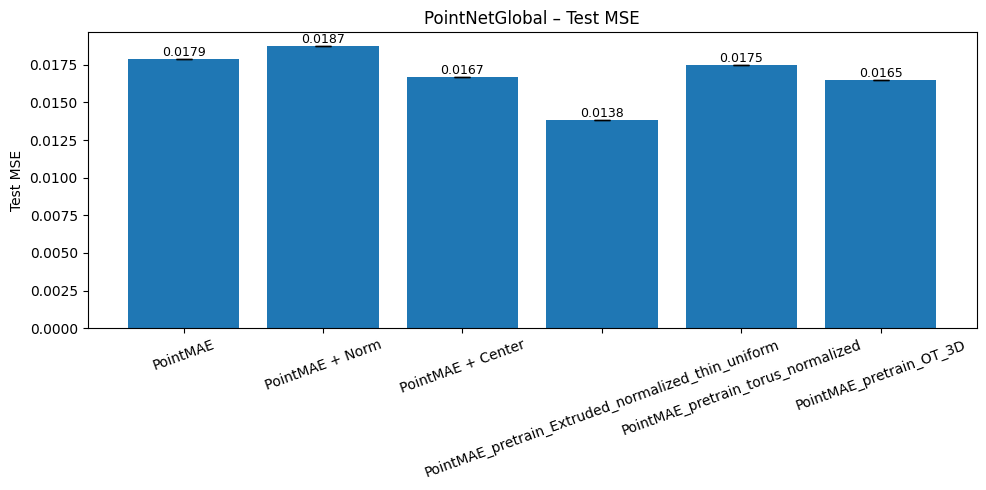

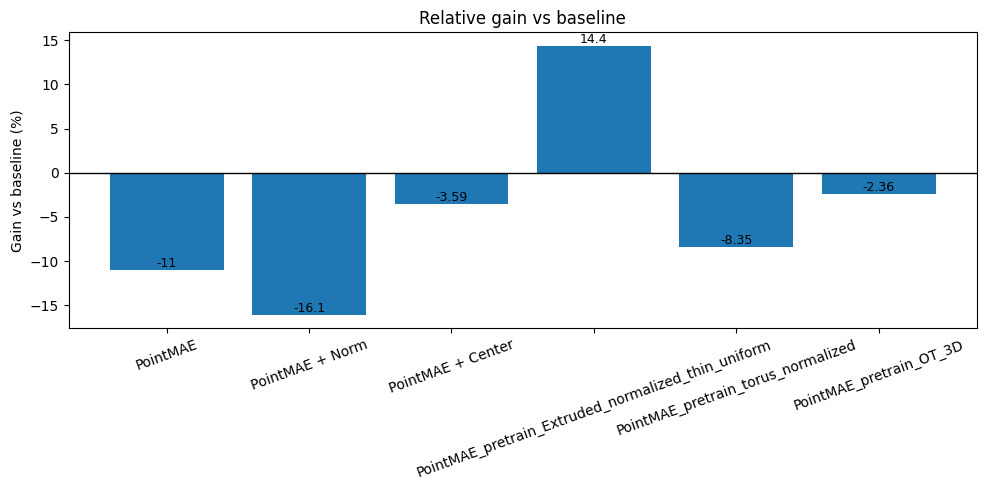

In [28]:
plot_empirical_bar(
    df,
    datasets=[
        "PointMAE_pretrain_default",
        "PointMAE_pretrain_normalized",
        "PointMAE_pretrain_centered",
        "PointMAE_pretrain_Extruded_normalized_thin_uniform",
        "PointMAE_pretrain_torus_normalized",
        "PointMAE_pretrain_OT_3D",
    ],
    models=["PointNetGlobal","PointNet"],
    title="PointNetGlobal – Test MSE"
)


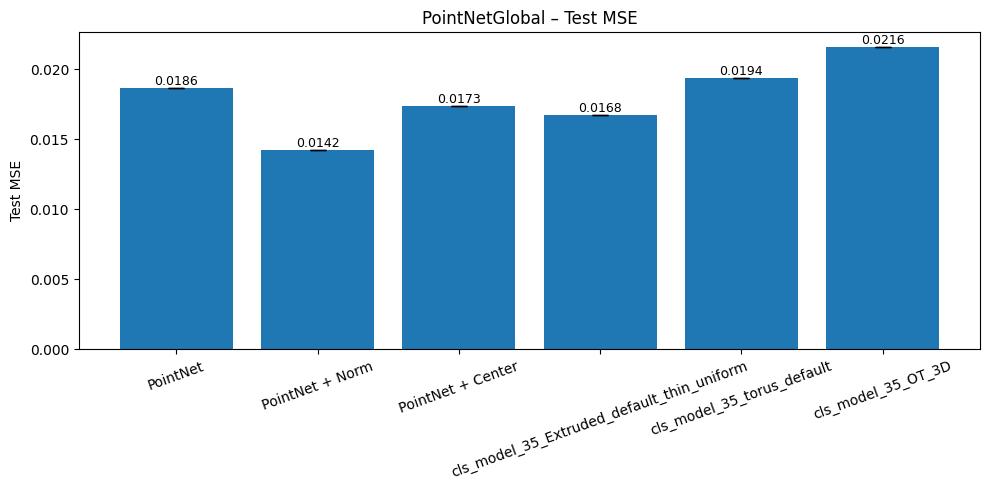

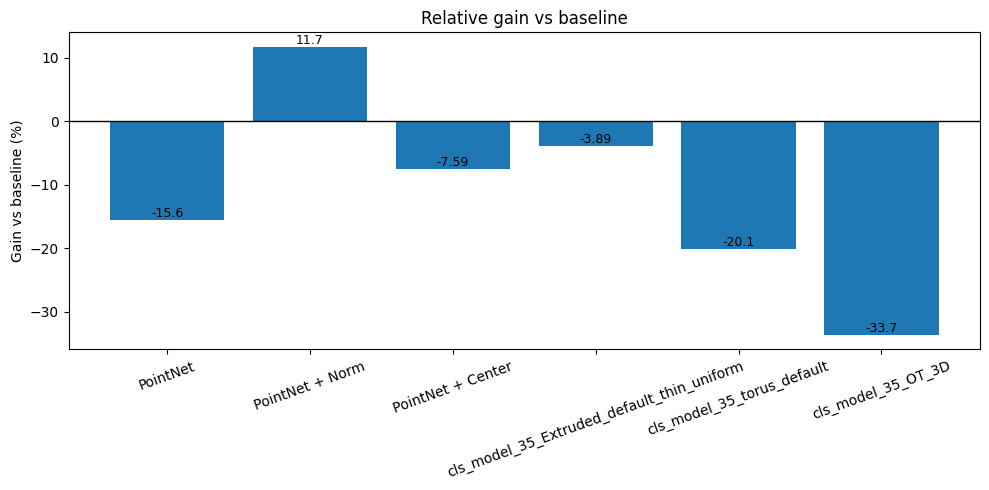

In [29]:
plot_empirical_bar(
    df,
    datasets=[
        "cls_model_35_default",
        "cls_model_35_normalized",
        "cls_model_35_centered",
        "cls_model_35_Extruded_default_thin_uniform",
        "cls_model_35_torus_default",
        "cls_model_35_OT_3D",
    ],
    models=["PointNetGlobal","PointNet"],
    title="PointNetGlobal – Test MSE"
)

# GuNetGlobal

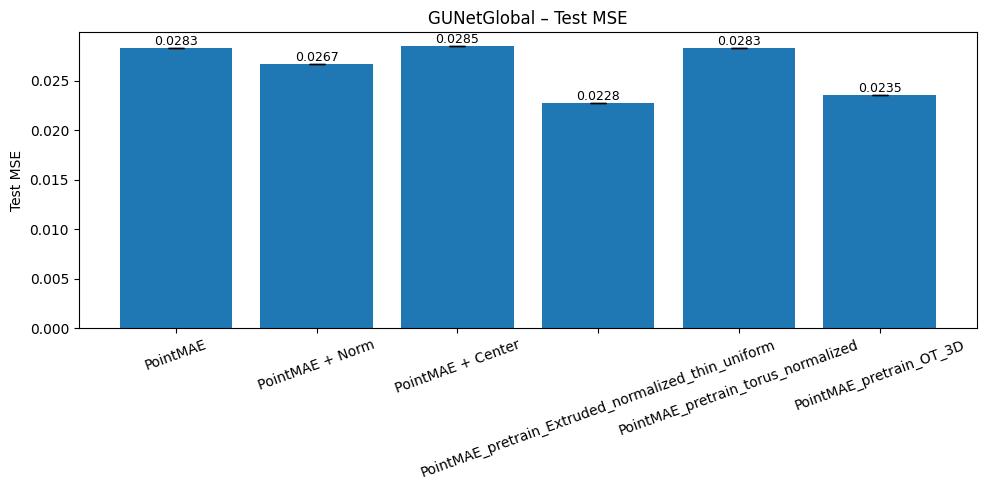

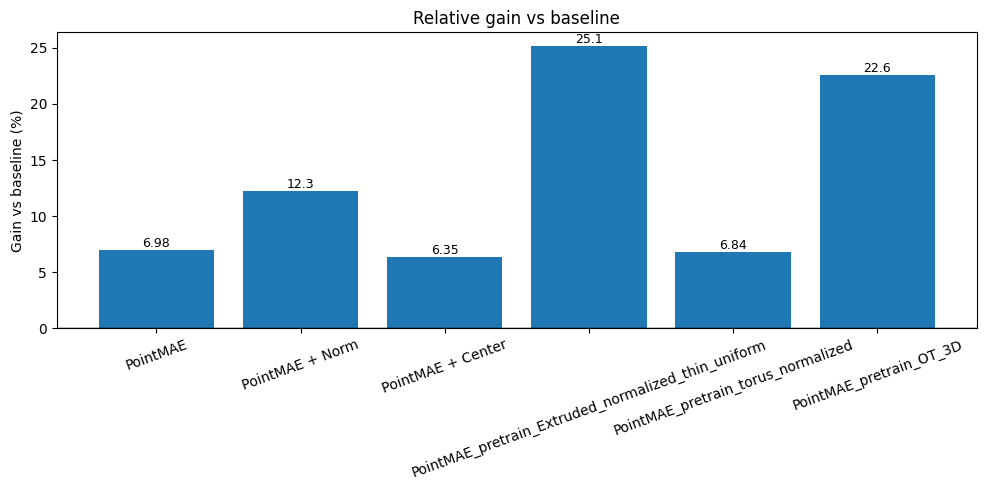

In [30]:
plot_empirical_bar(
    df,
    datasets=[
        "PointMAE_pretrain_default",
        "PointMAE_pretrain_normalized",
        "PointMAE_pretrain_centered",
        "PointMAE_pretrain_Extruded_normalized_thin_uniform",
        "PointMAE_pretrain_torus_normalized",
        "PointMAE_pretrain_OT_3D",
    ],
    models=["GUNetGlobal","GUNet"],
    title="GUNetGlobal – Test MSE"
)


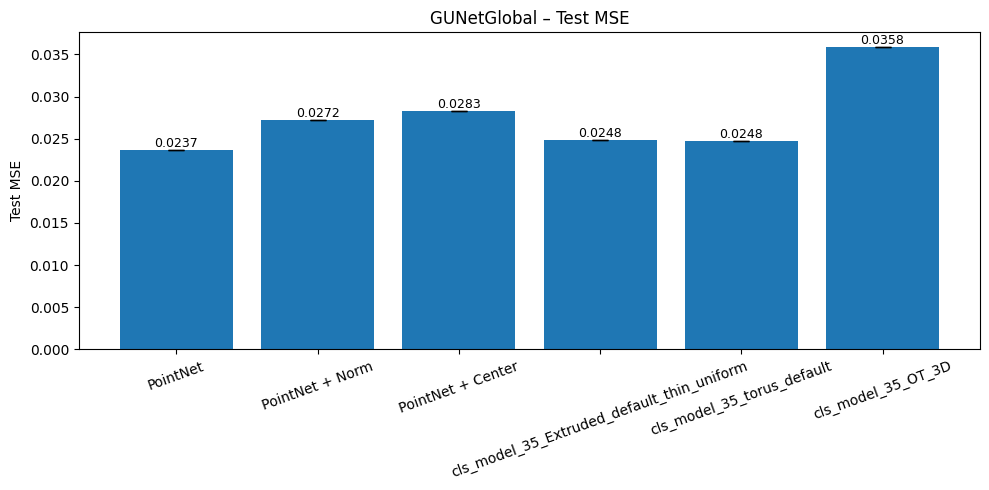

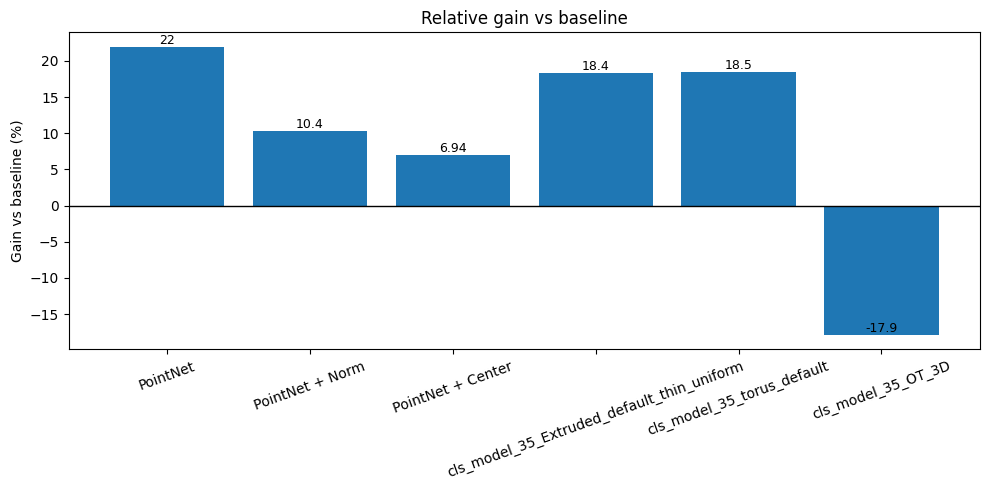

In [31]:
plot_empirical_bar(
    df,
    datasets=[
        "cls_model_35_default",
        "cls_model_35_normalized",
        "cls_model_35_centered",
        "cls_model_35_Extruded_default_thin_uniform",
        "cls_model_35_torus_default",
        "cls_model_35_OT_3D",
    ],
    models=["GUNetGlobal","GUNet"],
    title="GUNetGlobal – Test MSE"
)